# PhoBERT-based AI-Generated Vietnamese Text Detection

Binary classification model to detect AI-generated Vietnamese text using vinai/phobert-base.

**Labels:**
- 0 = AI-generated text
- 1 = Human-written text

## 1. Setup & Imports

In [ ]:
# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================
!pip install -q transformers torch pandas numpy scikit-learn matplotlib seaborn tqdm unicodedata2

In [ ]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================
import os
import re
import unicodedata
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, 
    AutoModel, 
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

/home/hhbach/anaconda3/envs/aigenDetection_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cuda
   GPU: NVIDIA RTX A4000
   Memory: 15.6 GB


## 2. Configuration

In [ ]:
# ============================================================
# 3. CONFIGURATION
# ============================================================
class Config:
    # Paths
    DATASET_PATH = "/home/hhbach/nlp_aigen_detection/kd_test_data"
    MODEL_SAVE_PATH = "/home/hhbach/nlp_aigen_detection/best_model_kd.pt"
    
    # Model
    MODEL_NAME = "vinai/phobert-base"
    MAX_LENGTH = 256
    
    # Training
    BATCH_SIZE = 16
    EPOCHS = 5
    LEARNING_RATE = 2e-5
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1
    
    # Split ratios
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15  # of remaining after test split
    
    # Labels
    LABEL_AI = 0
    LABEL_HUMAN = 1

print("📋 Configuration:")
for attr in dir(Config):
    if not attr.startswith('_'):
        print(f"   {attr}: {getattr(Config, attr)}")

📋 Configuration:
   BATCH_SIZE: 16
   DATASET_PATH: /home/hhbach/nlp_aigen_detection/kd_test_data
   EPOCHS: 5
   LABEL_AI: 0
   LABEL_HUMAN: 1
   LEARNING_RATE: 2e-05
   MAX_LENGTH: 256
   MODEL_NAME: vinai/phobert-base
   MODEL_SAVE_PATH: /home/hhbach/nlp_aigen_detection/best_model_kd.pt
   TEST_SIZE: 0.15
   VAL_SIZE: 0.15
   WARMUP_RATIO: 0.1
   WEIGHT_DECAY: 0.01


## 3. Data Loading

In [ ]:
# ============================================================
# 4. DATA LOADING FUNCTIONS
# ============================================================

import re

def read_text_file(filepath):
    """
    Read text file with multiple encoding attempts
    """
    encodings = ['utf-8', 'utf-16-le', 'utf-16-be', 'utf-16', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            with open(filepath, 'r', encoding=enc) as f:
                content = f.read()
                content = content.replace('\x00', '')
                return content
        except:
            continue
    
    # Binary fallback
    try:
        with open(filepath, 'rb') as f:
            content = f.read()
            content = content.decode('utf-8', errors='replace').replace('\x00', '')
            return content
    except:
        return ""


def extract_group_id(filename, label):
    """
    Extract group ID from filename for group-based splitting.
    CRITICAL: Adds AI/Human prefix to prevent mixing articles with same number
    from different sources.
    
    Format examples:
    - AI: "KD_ VNE_ (1905).txt" → "AI_article_1905"
    - Human: "KD_ VNE_ (100).txt" → "Human_article_100"
    """
    # Extract article number from parentheses
    match = re.search(r'\((\d+)\)', filename)
    if match:
        article_num = match.group(1)
        prefix = "AI" if label == 0 else "Human"
        return f"{prefix}_article_{article_num}"
    else:
        # Fallback: use filename without extension with prefix
        prefix = "AI" if label == 0 else "Human"
        return f"{prefix}_{filename.replace('.txt', '')}"


def load_dataset(base_path):
    """
    Load all text files from AI and Human folders
    Returns: DataFrame with columns [filepath, text, label, category, source, group_id]
    """
    data = []
    
    # Load AI files
    ai_path = os.path.join(base_path, "AI")
    for category in os.listdir(ai_path):
        cat_path = os.path.join(ai_path, category)
        if os.path.isdir(cat_path):
            for filename in os.listdir(cat_path):
                if filename.endswith('.txt'):
                    filepath = os.path.join(cat_path, filename)
                    text = read_text_file(filepath)
                    if text.strip():
                        # Parse source from filename
                        parts = filename.split('_')
                        source = parts[1] if len(parts) > 1 else 'Unknown'
                        
                        # Extract group_id for group-based splitting
                        group_id = extract_group_id(filename, Config.LABEL_AI)
                        
                        data.append({
                            'filepath': filepath,
                            'filename': filename,
                            'text': text,
                            'label': Config.LABEL_AI,
                            'category': category,
                            'source': source,
                            'group_id': group_id
                        })
    
    # Load Human files
    human_path = os.path.join(base_path, "Human")
    for category in os.listdir(human_path):
        cat_path = os.path.join(human_path, category)
        if os.path.isdir(cat_path):
            for filename in os.listdir(cat_path):
                if filename.endswith('.txt'):
                    filepath = os.path.join(cat_path, filename)
                    text = read_text_file(filepath)
                    if text.strip():
                        # Parse source from filename
                        parts = filename.split('_')
                        source = parts[1] if len(parts) > 1 else 'Unknown'
                        
                        # Extract group_id for group-based splitting
                        group_id = extract_group_id(filename, Config.LABEL_HUMAN)
                        
                        data.append({
                            'filepath': filepath,
                            'filename': filename,
                            'text': text,
                            'label': Config.LABEL_HUMAN,
                            'category': category,
                            'source': source,
                            'group_id': group_id
                        })
    
    df = pd.DataFrame(data)
    return df

# Load dataset
print("🔍 Loading dataset...")
df = load_dataset(Config.DATASET_PATH)
print(f"✅ Loaded {len(df)} samples")
print(f"\n📊 Label distribution:")
print(df['label'].value_counts().rename({0: 'AI', 1: 'Human'}))
print(f"\n📊 Category distribution:")
print(df['category'].value_counts())
print(f"\n📊 Group ID examples:")
print(df[['filename', 'group_id', 'label']].head(10))
print(f"\n📊 Total unique groups: {df['group_id'].nunique()}")

🔍 Loading dataset...
✅ Loaded 14823 samples

📊 Label distribution:
label
Human    8101
AI       6722
Name: count, dtype: int64

📊 Category distribution:
category
Doi song      4422
Kinh doanh    3572
Vi tinh       3472
Suc khoe      3357
Name: count, dtype: int64

📊 Group ID examples:
              filename         group_id  label
0  KD_ VNE_ (1943).txt  AI_article_1943      0
1    KD_TN_ (3152).txt  AI_article_3152      0
2   KD_ VNE_ (589).txt   AI_article_589      0
3   KD_ VNE_ (808).txt   AI_article_808      0
4    KD_TN_ (3278).txt  AI_article_3278      0
5    KD_ VNE_ (38).txt    AI_article_38      0
6  KD_ VNE_ (2386).txt  AI_article_2386      0
7   KD_NLD_ (3345).txt  AI_article_3345      0
8   KD_ VNE_ (742).txt   AI_article_742      0
9    KD_TT_ (2976).txt  AI_article_2976      0

📊 Total unique groups: 7749


## 4. Preprocessing

In [ ]:
# ============================================================
# 5. PREPROCESSING
# ============================================================

def preprocess_text(text):
    """
    Clean and normalize Vietnamese text
    """
    if not text:
        return ""
    
    # Unicode normalization (NFC)
    text = unicodedata.normalize('NFC', text)
    
    # Remove null bytes and control characters (except newlines)
    text = ''.join(char for char in text if char == '\n' or unicodedata.category(char)[0] != 'C')
    
    # Lowercase
    text = text.lower()
    
    # Strip whitespace but preserve newlines
    lines = [line.strip() for line in text.split('\n')]
    text = '\n'.join(line for line in lines if line)
    
    # Normalize multiple spaces/newlines
    text = re.sub(r' +', ' ', text)
    text = re.sub(r'\n+', '\n', text)
    
    return text.strip()

# Apply preprocessing
print("🧹 Preprocessing texts...")
tqdm.pandas()
df['text_processed'] = df['text'].progress_apply(preprocess_text)

# Remove empty texts
initial_len = len(df)
df = df[df['text_processed'].str.len() > 0].reset_index(drop=True)
print(f"✅ Preprocessing complete: {initial_len - len(df)} empty texts removed")
print(f"   Final dataset size: {len(df)}")

# Show sample
print(f"\n📝 Sample processed text:")
sample_idx = 0
print(f"   Label: {'AI' if df.iloc[sample_idx]['label'] == 0 else 'Human'}")
print(f"   Text: {df.iloc[sample_idx]['text_processed'][:200]}...")

🧹 Preprocessing texts...


100%|██████████| 14823/14823 [00:12<00:00, 1151.20it/s]

✅ Preprocessing complete: 0 empty texts removed
   Final dataset size: 14823

📝 Sample processed text:
   Label: AI
   Text: báo cáo chuyên đề kinh tế tư nhân số 16 của chương trình phát triển dự án me kong chỉ ra rằng thị trường chứng khoán việt nam đang chịu áp lực từ sự mất cân đối nghiêm trọng giữa cung và cầu. về phía ...


In [ ]:
# ============================================================
# 6. GROUP-BASED TRAIN/VAL/TEST SPLIT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

def group_based_split(df, test_size=0.15, val_size=0.15, random_state=42):
    """
    Perform group-based split to ensure all variants of the same text 
    stay together (prevent data leakage).
    
    Uses GroupShuffleSplit to group by 'group_id' column.
    Returns: train_df, val_df, test_df
    """
    print(f"📊 Total groups: {df['group_id'].nunique()}")
    print(f"📊 Total samples: {len(df)}")
    print(f"📊 Samples per group (avg): {len(df) / df['group_id'].nunique():.1f}")
    
    # First split: separate test set
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['group_id']))
    
    train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)
    
    # Second split: separate train and validation from remaining
    # val_size is proportion of original, so adjust for remaining data
    adjusted_val_size = val_size / (1 - test_size)
    
    gss_val = GroupShuffleSplit(n_splits=1, test_size=adjusted_val_size, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['group_id']))
    
    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_val_df.iloc[val_idx].reset_index(drop=True)
    
    return train_df, val_df, test_df

# Perform group-based split
print("✂️ Splitting data by groups (70/15/15)...")
print("="*60)
train_df, val_df, test_df = group_based_split(
    df, 
    test_size=Config.TEST_SIZE, 
    val_size=Config.VAL_SIZE
)

print(f"\n📊 Split sizes:")
print(f"   Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%) - {train_df['group_id'].nunique()} groups")
print(f"   Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%) - {val_df['group_id'].nunique()} groups")
print(f"   Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%) - {test_df['group_id'].nunique()} groups")

# Verify group separation (no overlap)
train_groups = set(train_df['group_id'].unique())
val_groups = set(val_df['group_id'].unique())
test_groups = set(test_df['group_id'].unique())

print(f"\n🔍 Group overlap check:")
print(f"   Train ∩ Val: {len(train_groups & val_groups)} groups (should be 0)")
print(f"   Train ∩ Test: {len(train_groups & test_groups)} groups (should be 0)")
print(f"   Val ∩ Test: {len(val_groups & test_groups)} groups (should be 0)")

# Verify label distribution
print(f"\n📊 Label distribution (should be similar across splits):")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split_df['label'].value_counts(normalize=True)
    ai_pct = dist.get(0, 0) * 100
    human_pct = dist.get(1, 0) * 100
    print(f"   {split_name}: AI={ai_pct:.1f}%, Human={human_pct:.1f}%")

✂️ Splitting data by groups (70/15/15)...
📊 Total groups: 7749
📊 Total samples: 14823
📊 Samples per group (avg): 1.9

📊 Split sizes:
   Train: 10391 (70.1%) - 5423 groups
   Validation: 2204 (14.9%) - 1163 groups
   Test: 2228 (15.0%) - 1163 groups

🔍 Group overlap check:
   Train ∩ Val: 0 groups (should be 0)
   Train ∩ Test: 0 groups (should be 0)
   Val ∩ Test: 0 groups (should be 0)

📊 Label distribution (should be similar across splits):
   Train: AI=45.1%, Human=54.9%
   Val: AI=45.2%, Human=54.8%
   Test: AI=46.5%, Human=53.5%


In [ ]:
# ## ⚠️ REMOVED: Stratified Split

# **This cell has been intentionally removed to prevent data leakage.**

# ### Why?
# The `stratified_split` function was overwriting the `group_based_split` results, causing **data leakage** where:
# - Multiple variants of the same article (e.g., C-001.txt, CL-001.txt, G-001.txt from same prompt) could end up in both train and test sets
# - This artificially inflated test accuracy (model saw similar texts during training)

# ### Solution
# Use only the **Group-Based Split** from the previous cell, which ensures:
# - All variants of the same article stay together in the same split
# - No information leakage between train/val/test sets
# - More realistic evaluation of model generalization

# ### To use this notebook correctly:
# 1. Run all cells in order
# 2. Skip/ignore this cell
# 3. Ensure you're using `train_df`, `val_df`, `test_df` from the Group-Based Split (previous cell)

# # ============================================================
# # 6. STRATIFIED TRAIN/VAL/TEST SPLIT
# # ============================================================
 
# def stratified_split(df, test_size=0.15, val_size=0.15, random_state=42):
#     """
#     Perform stratified split to maintain label distribution
#     Returns: train_df, val_df, test_df
#     """
#     # First split: separate test set
#     train_val_df, test_df = train_test_split(
#         df, 
#         test_size=test_size, 
#         random_state=random_state, 
#         stratify=df['label']
#     )
 
#     # Second split: separate train and validation
#     # val_size is proportion of original, so adjust for remaining data
#     adjusted_val_size = val_size / (1 - test_size)
 
#     train_df, val_df = train_test_split(
#         train_val_df,
#         test_size=adjusted_val_size,
#         random_state=random_state,
#         stratify=train_val_df['label']
#     )
 
#     return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)
 
# # Perform split
# print("✂️ Splitting data (70/15/15)...")
# train_df, val_df, test_df = stratified_split(
#     df, 
#     test_size=Config.TEST_SIZE, 
#     val_size=Config.VAL_SIZE
# )
 
# print(f"\n📊 Split sizes:")
# print(f"   Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
# print(f"   Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
# print(f"   Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
 
# # Verify stratification
# print(f"\n📊 Label distribution (should be similar across splits):")
# for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
#     dist = split_df['label'].value_counts(normalize=True)
#     ai_pct = dist.get(0, 0) * 100
#     human_pct = dist.get(1, 0) * 100
#     print(f"   {split_name}: AI={ai_pct:.1f}%, Human={human_pct:.1f}%")

## 6. PhoBERT Tokenization

In [ ]:
# ============================================================
# 7. TOKENIZATION
# ============================================================

print("🔤 Loading PhoBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)
print(f"✅ Loaded tokenizer: {Config.MODEL_NAME}")

# Test tokenization
sample_text = train_df.iloc[0]['text_processed'][:100]
sample_tokens = tokenizer(
    sample_text, 
    max_length=Config.MAX_LENGTH, 
    padding='max_length', 
    truncation=True, 
    return_tensors='pt'
)
print(f"\n📝 Tokenization example:")
print(f"   Input text: {sample_text[:50]}...")
print(f"   Token count: {sample_tokens['input_ids'].shape[1]}")
print(f"   Input IDs shape: {sample_tokens['input_ids'].shape}")

🔤 Loading PhoBERT tokenizer...


✅ Loaded tokenizer: vinai/phobert-base

📝 Tokenization example:
   Input text: báo cáo chuyên đề kinh tế tư nhân số 16 của chương...
   Token count: 256
   Input IDs shape: torch.Size([1, 256])


## 7. Dataset Class & DataLoader

In [ ]:
# ============================================================
# 8. CUSTOM DATASET CLASS
# ============================================================

class AIDetectionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.texts = df['text_processed'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
print("📦 Creating datasets...")
train_dataset = AIDetectionDataset(train_df, tokenizer, Config.MAX_LENGTH)
val_dataset = AIDetectionDataset(val_df, tokenizer, Config.MAX_LENGTH)
test_dataset = AIDetectionDataset(test_df, tokenizer, Config.MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=True, 
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

📦 Creating datasets...
✅ DataLoaders created:
   Train batches: 650
   Val batches: 138
   Test batches: 140


In [ ]:
# Kiểm tra group overlap sau khi chạy cả 2 cell split
print("Số lượng group_id unique:", df['group_id'].nunique())
print("Ví dụ group_id:", df['group_id'].unique()[:10])
print("\nTổng số samples:", len(df))

# Kiểm tra xem có duplicate text không
print("\nSố text trùng lặp:", df['text_processed'].duplicated().sum())

Số lượng group_id unique: 7749
Ví dụ group_id: <ArrowStringArray>
['AI_article_1943', 'AI_article_3152',  'AI_article_589',  'AI_article_808',
 'AI_article_3278',   'AI_article_38', 'AI_article_2386', 'AI_article_3345',
  'AI_article_742', 'AI_article_2976']
Length: 10, dtype: str

Tổng số samples: 14823

Số text trùng lặp: 1


## 8. Model Architecture

In [ ]:
# ============================================================
# 9. MODEL ARCHITECTURE
# ============================================================

class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout_rate=0.1):
        super(PhoBERTClassifier, self).__init__()
        
        # Load pre-trained PhoBERT
        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.bert.config.hidden_size
        
        # Classification head
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        # Get BERT outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Use [CLS] token representation (first token)
        pooled_output = outputs.last_hidden_state[:, 0]
        
        # Apply dropout and classification
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        
        return logits

# Initialize model
print("🤖 Initializing model...")
model = PhoBERTClassifier(Config.MODEL_NAME, num_classes=2)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model initialized")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   BERT hidden size: {model.hidden_size}")

🤖 Initializing model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8637.58it/s]
RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model initialized
   Total parameters: 134,999,810
   Trainable parameters: 134,999,810
   BERT hidden size: 768


## 9. Training Setup

In [ ]:
# ============================================================
# 10. TRAINING SETUP WITH VERIFICATION
# ============================================================

# Calculate class weights for imbalance handling
n_samples = len(train_df)
n_ai = len(train_df[train_df['label'] == 0])
n_human = len(train_df[train_df['label'] == 1])

weight_ai = n_samples / (2 * n_ai)
weight_human = n_samples / (2 * n_human)
class_weights = torch.tensor([weight_ai, weight_human], dtype=torch.float).to(device)

print(f"📊 Class distribution in training set:")
print(f"   AI: {n_ai} samples")
print(f"   Human: {n_human} samples")
print(f"   Class weights: AI={weight_ai:.4f}, Human={weight_human:.4f}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with different learning rates for BERT and classifier
bert_params = list(model.bert.named_parameters())
classifier_params = list(model.dropout.named_parameters()) + list(model.classifier.named_parameters())

# Use higher learning rate for classifier, lower for BERT
optimizer_grouped_parameters = [
    {'params': [p for n, p in bert_params], 'lr': Config.LEARNING_RATE},
    {'params': [p for n, p in classifier_params], 'lr': Config.LEARNING_RATE * 10}  # 10x for classifier
]

optimizer = AdamW(optimizer_grouped_parameters, weight_decay=Config.WEIGHT_DECAY)

# Learning rate scheduler
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * Config.EPOCHS
warmup_steps = int(total_steps * Config.WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n" + "="*60)
print(f"⚙️ TRAINING CONFIGURATION VERIFICATION")
print(f"="*60)
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total epochs: {Config.EPOCHS}")
print(f"   Total steps: {total_steps}")
print(f"   Warmup ratio: {Config.WARMUP_RATIO} ({Config.WARMUP_RATIO*100:.0f}%)")
print(f"   Warmup steps: {warmup_steps}")
print(f"   Warmup duration: ~{warmup_steps/steps_per_epoch:.1f} epochs")
print(f"="*60)
print(f"\n📚 Learning Rates:")
print(f"   BERT layers: {Config.LEARNING_RATE}")
print(f"   Classifier: {Config.LEARNING_RATE * 10}")
print(f"   Weight decay: {Config.WEIGHT_DECAY}")
print(f"   Batch size: {Config.BATCH_SIZE}")

# Verify scheduler is correctly set
print(f"\n✅ Scheduler verification:")
print(f"   Type: {type(scheduler).__name__}")
print(f"   Step() per: batch (correct for transformers)")
print(f"   First LR after warmup: ~{Config.LEARNING_RATE:.2e}")

📊 Class distribution in training set:
   AI: 4690 samples
   Human: 5701 samples
   Class weights: AI=1.1078, Human=0.9113

⚙️ TRAINING CONFIGURATION VERIFICATION
   Steps per epoch: 650
   Total epochs: 5
   Total steps: 3250
   Warmup ratio: 0.1 (10%)
   Warmup steps: 325
   Warmup duration: ~0.5 epochs

📚 Learning Rates:
   BERT layers: 2e-05
   Classifier: 0.0002
   Weight decay: 0.01
   Batch size: 16

✅ Scheduler verification:
   Type: LambdaLR
   Step() per: batch (correct for transformers)
   First LR after warmup: ~2.00e-05


In [ ]:
# ============================================================
# 11. TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    total_grad_norm = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for batch_idx, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        
        # Calculate gradient norm for monitoring
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        total_grad_norm += grad_norm.item()
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Collect predictions
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar with more info
        if batch_idx % 50 == 0:
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'grad_norm': f'{grad_norm.item():.2f}'
            })
    
    avg_loss = total_loss / len(dataloader)
    avg_grad_norm = total_grad_norm / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy, avg_grad_norm


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            
            # Get predictions and probabilities
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Prob of class 1 (Human)
    
    avg_loss = total_loss / len(dataloader)
    
    # Calculate metrics
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
        'roc_auc': roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5,
        'predictions': all_preds,
        'labels': all_labels,
        'probs': all_probs
    }
    
    return metrics

## 10. Training Loop

In [ ]:
# ============================================================
# 12. TRAINING LOOP
# ============================================================

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'train_grad_norm': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_val_f1 = 0
best_model_state = None

print("\n🚀 Starting training...")
print("="*60)

for epoch in range(Config.EPOCHS):
    print(f"\n📌 Epoch {epoch + 1}/{Config.EPOCHS}")
    print("-"*60)
    
    # Training
    train_loss, train_acc, train_grad_norm = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    
    # Validation
    val_metrics = evaluate(model, val_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_grad_norm'].append(train_grad_norm)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])
    
    # Print metrics
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Grad Norm: {train_grad_norm:.2f}")
    print(f"   Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
    print(f"   Val Precision: {val_metrics['precision']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
    print(f"   Val F1: {val_metrics['f1']:.4f} | Val ROC-AUC: {val_metrics['roc_auc']:.4f}")
    
    # Save best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_model_state = model.state_dict().copy()
        print(f"   🌟 New best model saved! (Val F1: {best_val_f1:.4f})")

print("\n" + "="*60)
print(f"✅ Training complete! Best Val F1: {best_val_f1:.4f}")


🚀 Starting training...

📌 Epoch 1/5
------------------------------------------------------------


Evaluating: 100%|██████████| 138/138 [00:15<00:00,  8.78it/s]


   Train Loss: 0.1097 | Train Acc: 0.9559 | Grad Norm: 4.60
   Val Loss: 0.0312 | Val Acc: 0.9950
   Val Precision: 0.9950 | Val Recall: 0.9950
   Val F1: 0.9950 | Val ROC-AUC: 0.9999
   🌟 New best model saved! (Val F1: 0.9950)

📌 Epoch 2/5
------------------------------------------------------------


Evaluating: 100%|██████████| 138/138 [00:15<00:00,  8.85it/s]


   Train Loss: 0.0081 | Train Acc: 0.9982 | Grad Norm: 1.50
   Val Loss: 0.0121 | Val Acc: 0.9977
   Val Precision: 0.9977 | Val Recall: 0.9977
   Val F1: 0.9977 | Val ROC-AUC: 1.0000
   🌟 New best model saved! (Val F1: 0.9977)

📌 Epoch 3/5
------------------------------------------------------------


...

   Train Loss: 0.0020 | Train Acc: 0.9995 | Grad Norm: 0.48
   Val Loss: 0.0118 | Val Acc: 0.9982
   Val Precision: 0.9982 | Val Recall: 0.9982
   Val F1: 0.9982 | Val ROC-AUC: 0.9999
   🌟 New best model saved! (Val F1: 0.9982)

📌 Epoch 4/5
------------------------------------------------------------


Evaluating: 100%|██████████| 138/138 [00:15<00:00,  8.99it/s]


   Train Loss: 0.0000 | Train Acc: 1.0000 | Grad Norm: 0.00
   Val Loss: 0.0170 | Val Acc: 0.9973
   Val Precision: 0.9973 | Val Recall: 0.9973
   Val F1: 0.9973 | Val ROC-AUC: 1.0000

📌 Epoch 5/5
------------------------------------------------------------


Evaluating: 100%|██████████| 138/138 [00:15<00:00,  8.96it/s]


   Train Loss: 0.0000 | Train Acc: 1.0000 | Grad Norm: 0.02
   Val Loss: 0.0094 | Val Acc: 0.9986
   Val Precision: 0.9986 | Val Recall: 0.9986
   Val F1: 0.9986 | Val ROC-AUC: 1.0000
   🌟 New best model saved! (Val F1: 0.9986)

✅ Training complete! Best Val F1: 0.9986


## 11. Save Best Model

In [ ]:
# ============================================================
# 13. SAVE BEST MODEL
# ============================================================

if best_model_state is not None:
    # Save model checkpoint
    checkpoint = {
        'model_state_dict': best_model_state,
        'config': {
            'model_name': Config.MODEL_NAME,
            'max_length': Config.MAX_LENGTH,
            'hidden_size': model.hidden_size
        },
        'best_val_f1': best_val_f1
    }
    
    torch.save(checkpoint, Config.MODEL_SAVE_PATH)
    print(f"💾 Best model saved to: {Config.MODEL_SAVE_PATH}")
    
    # Load best model for evaluation
    model.load_state_dict(best_model_state)
else:
    print("⚠️ No best model found, using last epoch")

💾 Best model saved to: /home/hhbach/nlp_aigen_detection/best_model_kd.pt


## 12. Test Set Evaluation


📊 Evaluating on Test Set...


Evaluating: 100%|██████████| 140/140 [00:15<00:00,  9.03it/s]



🎯 Test Set Results:
   Accuracy: 0.9991
   Precision: 0.9991
   Recall: 0.9991
   F1-Score: 0.9991
   ROC-AUC: 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

          AI       1.00      1.00      1.00      1035
       Human       1.00      1.00      1.00      1193

    accuracy                           1.00      2228
   macro avg       1.00      1.00      1.00      2228
weighted avg       1.00      1.00      1.00      2228


📊 PROBABILITY DISTRIBUTION ANALYSIS (Overconfidence Check)

📈 Statistics:
   Mean prob (Human class): 0.5363
   Std prob: 0.4986
   Min prob: 0.0000
   Max prob: 1.0000

📊 Distribution:
   Prob < 0.1 (Strong AI prediction): 1033 samples (46.4%)
   Prob 0.1-0.9 (Uncertain): 1 samples (0.0%)
   Prob > 0.9 (Strong Human prediction): 1194 samples (53.6%)


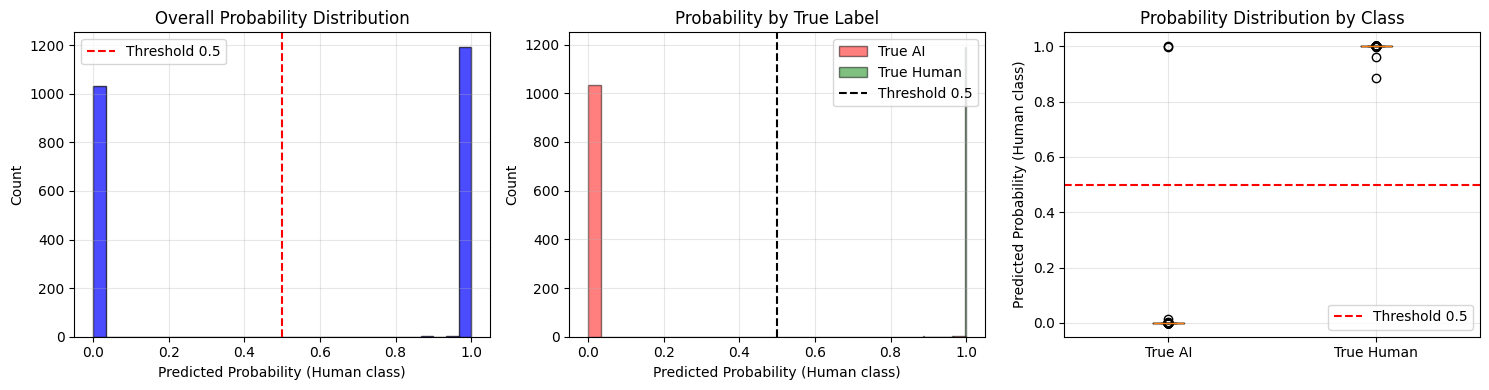


✅ Probability distribution saved to: probability_distribution.png

⚠️  WARNING: Model is OVERCONFIDENT!
    >95% of predictions have extreme probabilities (<0.1 or >0.9)
    This suggests possible data leakage or overfitting.


In [ ]:
# ============================================================  
# 14. TEST SET EVALUATION WITH PROBABILITY ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("\n📊 Evaluating on Test Set...")
print("="*60)

test_metrics = evaluate(model, test_loader, criterion, device)

print(f"\n🎯 Test Set Results:")
print(f"   Accuracy: {test_metrics['accuracy']:.4f}")
print(f"   Precision: {test_metrics['precision']:.4f}")
print(f"   Recall: {test_metrics['recall']:.4f}")
print(f"   F1-Score: {test_metrics['f1']:.4f}")
print(f"   ROC-AUC: {test_metrics['roc_auc']:.4f}")

# Classification report
print("\n📋 Classification Report:")
print(classification_report(
    test_metrics['labels'], 
    test_metrics['predictions'], 
    target_names=['AI', 'Human']
))

# ============================================================
# PROBABILITY DISTRIBUTION ANALYSIS
# ============================================================
print("\n" + "="*60)
print("📊 PROBABILITY DISTRIBUTION ANALYSIS (Overconfidence Check)")
print("="*60)

all_probs = np.array(test_metrics['probs'])
all_labels = np.array(test_metrics['labels'])

# Separate by true label
ai_probs = all_probs[all_labels == 0]
human_probs = all_probs[all_labels == 1]

print(f"\n📈 Statistics:")
print(f"   Mean prob (Human class): {np.mean(all_probs):.4f}")
print(f"   Std prob: {np.std(all_probs):.4f}")
print(f"   Min prob: {np.min(all_probs):.4f}")
print(f"   Max prob: {np.max(all_probs):.4f}")

print(f"\n📊 Distribution:")
print(f"   Prob < 0.1 (Strong AI prediction): {sum(all_probs < 0.1)} samples ({sum(all_probs < 0.1)/len(all_probs)*100:.1f}%)")
print(f"   Prob 0.1-0.9 (Uncertain): {sum((all_probs >= 0.1) & (all_probs <= 0.9))} samples ({sum((all_probs >= 0.1) & (all_probs <= 0.9))/len(all_probs)*100:.1f}%)")
print(f"   Prob > 0.9 (Strong Human prediction): {sum(all_probs > 0.9)} samples ({sum(all_probs > 0.9)/len(all_probs)*100:.1f}%)")

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Overall distribution
axes[0].hist(all_probs, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(x=0.5, color='r', linestyle='--', label='Threshold 0.5')
axes[0].set_xlabel('Predicted Probability (Human class)')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall Probability Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# By true label
axes[1].hist(ai_probs, bins=30, alpha=0.5, label='True AI', color='red', edgecolor='black')
axes[1].hist(human_probs, bins=30, alpha=0.5, label='True Human', color='green', edgecolor='black')
axes[1].axvline(x=0.5, color='k', linestyle='--', label='Threshold 0.5')
axes[1].set_xlabel('Predicted Probability (Human class)')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability by True Label')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Box plot
box_data = [ai_probs, human_probs]
axes[2].boxplot(box_data, labels=['True AI', 'True Human'])
axes[2].axhline(y=0.5, color='r', linestyle='--', label='Threshold 0.5')
axes[2].set_ylabel('Predicted Probability (Human class)')
axes[2].set_title('Probability Distribution by Class')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/hhbach/nlp_aigen_detection/probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Probability distribution saved to: probability_distribution.png")

# Overconfidence warning
if sum(all_probs < 0.1) + sum(all_probs > 0.9) > len(all_probs) * 0.95:
    print("\n⚠️  WARNING: Model is OVERCONFIDENT!")
    print("    >95% of predictions have extreme probabilities (<0.1 or >0.9)")
    print("    This suggests possible data leakage or overfitting.")
else:
    print("\n✅ Probability distribution looks reasonable (not overconfident)")

## 13. Visualization

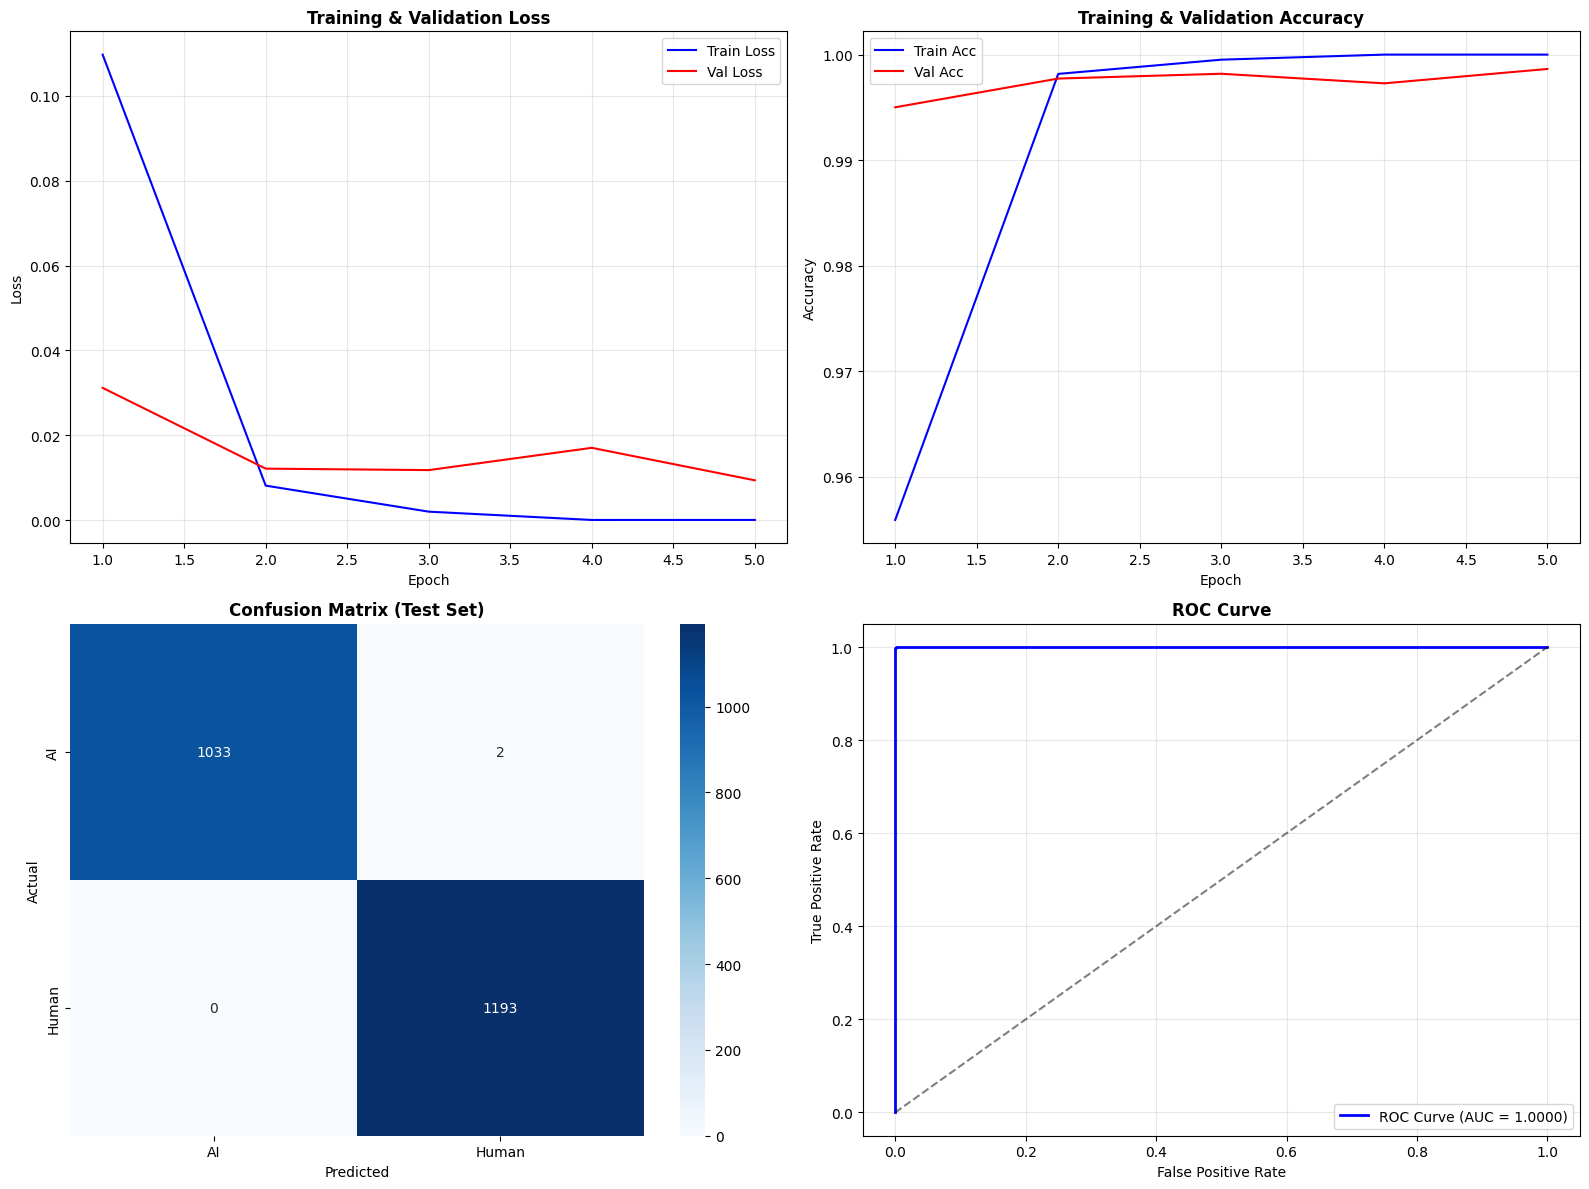

✅ Results saved to: training_results.png


In [ ]:
# ============================================================
# 15. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training curves
epochs_range = range(1, Config.EPOCHS + 1)
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
axes[0, 0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy curves
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc')
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
axes[0, 1].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['AI', 'Human'], yticklabels=['AI', 'Human'])
axes[1, 0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# 4. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(test_metrics['labels'], test_metrics['probs'])
axes[1, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {test_metrics["roc_auc"]:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/hhbach/nlp_aigen_detection/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Results saved to: training_results.png")

## 14. Inference Function

In [ ]:
# ============================================================
# 16. INFERENCE FUNCTION
# ============================================================

def predict_text(text, model, tokenizer, device, max_length=256):
    """
    Predict whether a text is AI-generated or Human-written
    """
    model.eval()
    
    # Preprocess
    text = preprocess_text(text)
    
    # Tokenize
    encoding = tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(logits, dim=1).item()
    
    label = 'Human' if pred == 1 else 'AI'
    confidence = probs[0][pred].item()
    
    return {
        'label': label,
        'confidence': confidence,
        'prob_ai': probs[0][0].item(),
        'prob_human': probs[0][1].item(),
        'logits': logits.cpu().numpy()  # Add raw logits for debugging
    }

# Test on sample texts
print("📝 Testing inference on sample texts:\n")

# Get one AI and one Human sample from test set
# ai_sample = test_df[test_df['label'] == 0].iloc[13]['text_processed'][:300]
# human_sample = test_df[test_df['label'] == 1].iloc[13]['text_processed'][:300]

ai_sample = """
Sáng 15/3, trên 79 triệu cử tri cả nước cùng đi dự ngày hội bầu chọn đại biểu Quốc hội khóa 16 với HĐND các cấp nhiệm kỳ 2026-2031.

Từ sớm, Tổng Bí thư Tô Lâm đã tới lễ khai mạc rồi thực hiện bỏ phiếu tại địa điểm trường THPT Phan Đình Phùng, khu vực bỏ phiếu số 2, phường Ba Đình, Hà Nội. Cùng đi bầu cử ở điểm bỏ phiếu này có Thường trực Ban Bí thư Trần Cẩm Tú, Trưởng ban Tổ chức Trung ương Lê Minh Hưng, Trưởng ban Nội chính Trung ương Lê Minh Trí, Chánh Văn phòng Trung ương Đảng Phạm Gia Túc, Bí thư Thành ủy Hà Nội Nguyễn Duy Ngọc.
Đúng 7h15, Tổng Bí thư Tô Lâm cùng Thường trực Ban Bí thư Trần Cẩm Tú viết phiếu rồi bỏ phiếu bầu đại biểu Quốc hội khóa 16 cùng đại biểu HĐND các cấp nhiệm kỳ 2026-2031.

Khi bỏ phiếu xong, Tổng Bí thư Tô Lâm hỏi thăm cử tri ở điểm bỏ phiếu rồi dành thời gian trả lời phỏng vấn báo chí. Ông nói rất phấn chấn lúc thực hiện quyền cử tri đồng thời chứng kiến đông đảo người dân cùng đi bỏ phiếu.

Tổng Bí thư chia sẻ cuộc bầu cử là lựa chọn những người được nhân dân tin tưởng để đại diện cho ý chí, nguyện vọng của cử tri rồi cùng quyết định các vấn đề then chốt của đất nước.óp phần quyết định các vấn đề quan trọng của đất nước trong thời gian tới.
"""

human_sample ="""
Sáng 15/3, hơn 79 triệu cử tri toàn quốc tham gia ngày hội bầu cử đại biểu Quốc hội khóa 16 và HĐND các cấp nhiệm kỳ 2026-2031.

Từ sớm, Tổng Bí thư Tô Lâm đến dự khai mạc và tham gia bầu cử tại điểm bỏ phiếu trường THPT Phan Đình Phùng, khu vực bỏ phiếu số 2, phường Ba Đình, Hà Nội. Cùng tham gia bầu cử tại điểm bỏ phiếu này có Thường trực Ban Bí thư Trần Cẩm Tú, Trưởng ban Tổ chức Trung ương Lê Minh Hưng, Trưởng ban Nội chính Trung ương Lê Minh Trí, Chánh Văn phòng Trung ương Đảng Phạm Gia Túc, Bí thư Thành ủy Hà Nội Nguyễn Duy Ngọc.
Lúc 7h15, Tổng Bí thư Tô Lâm và Thường trực Ban Bí thư Trần Cẩm Tú ghi phiếu và bỏ phiếu bầu đại biểu Quốc hội khóa 16 và đại biểu HĐND các cấp nhiệm kỳ 2026-2031.

Sau khi bỏ phiếu, Tổng Bí thư Tô Lâm thăm hỏi cử tri tại điểm bỏ phiếu và dành thời gian trả lời phỏng vấn báo chí. Ông bày tỏ rất phấn khởi khi thực hiện quyền cử tri và chứng kiến đông đảo người dân tham gia bỏ phiếu.

Tổng Bí thư cho biết cuộc bầu cử nhằm lựa chọn những người được nhân dân tín nhiệm để đại diện cho ý chí, nguyện vọng của cử tri và tham gia quyết định các vấn đề quan trọng của đất nước.
"""

print("Sample 1 (Expected: AI):")
result1 = predict_text(ai_sample, model, tokenizer, device)
print(f"   Text: {ai_sample[:100]}...")
print(f"   Prediction: {result1['label']} (confidence: {result1['confidence']:.4f})")
print(f"   Prob AI: {result1['prob_ai']:.4f}, Prob Human: {result1['prob_human']:.4f}")
print(f"   Raw logits: {result1['logits']}")

print("\nSample 2 (Expected: Human):")
result2 = predict_text(human_sample, model, tokenizer, device)
print(f"   Text: {human_sample[:100]}...")
print(f"   Prediction: {result2['label']} (confidence: {result2['confidence']:.4f})")
print(f"   Prob AI: {result2['prob_ai']:.4f}, Prob Human: {result2['prob_human']:.4f}")
print(f"   Raw logits: {result2['logits']}")

📝 Testing inference on sample texts:

Sample 1 (Expected: AI):
   Text: 
Sáng 15/3, trên 79 triệu cử tri cả nước cùng đi dự ngày hội bầu chọn đại biểu Quốc hội khóa 16 với ...
   Prediction: Human (confidence: 1.0000)
   Prob AI: 0.0000, Prob Human: 1.0000
   Raw logits: [[-5.6174064  5.5772724]]

Sample 2 (Expected: Human):
   Text: 
Sáng 15/3, hơn 79 triệu cử tri toàn quốc tham gia ngày hội bầu cử đại biểu Quốc hội khóa 16 và HĐND...
   Prediction: Human (confidence: 1.0000)
   Prob AI: 0.0000, Prob Human: 1.0000
   Raw logits: [[-5.5311112  5.527488 ]]


## 15. Diagnostic Analysis (Debug)

In [ ]:
# ============================================================
# 17. DIAGNOSTIC ANALYSIS - Check Model Behavior
# ============================================================

print("="*60)
print("🔍 DIAGNOSTIC ANALYSIS")
print("="*60)

# 1. Check training curves
print("\n📈 Training Progress Check:")
if len(history['train_loss']) > 0:
    initial_loss = history['train_loss'][0]
    final_loss = history['train_loss'][-1]
    print(f"   Initial train loss: {initial_loss:.4f}")
    print(f"   Final train loss: {final_loss:.4f}")
    print(f"   Loss decreased: {'✅ Yes' if final_loss < initial_loss else '❌ No - MODEL NOT LEARNING!'}")
    
    initial_acc = history['train_acc'][0]
    final_acc = history['train_acc'][-1]
    print(f"   Initial train acc: {initial_acc:.4f}")
    print(f"   Final train acc: {final_acc:.4f}")
else:
    print("   ⚠️ No training history found!")

# 2. Analyze prediction distribution on test set
print("\n📊 Prediction Distribution Analysis:")
unique, counts = np.unique(test_metrics['predictions'], return_counts=True)
print(f"   Predicted classes: {dict(zip(unique, counts))}")
print(f"   Predicted AI: {counts[0] if 0 in unique else 0} ({counts[0]/len(test_metrics['predictions'])*100 if 0 in unique else 0:.1f}%)")
print(f"   Predicted Human: {counts[1] if 1 in unique else 0} ({counts[1]/len(test_metrics['predictions'])*100 if 1 in unique else 0:.1f}%)")

# 3. Analyze probability distribution
probs_array = np.array(test_metrics['probs'])
print(f"\n📊 Probability Statistics (Human class):")
print(f"   Mean: {probs_array.mean():.4f}")
print(f"   Std: {probs_array.std():.4f}")
print(f"   Min: {probs_array.min():.4f}")
print(f"   Max: {probs_array.max():.4f}")

if probs_array.mean() > 0.9:
    print("   ⚠️ WARNING: Model predicts 'Human' for almost everything!")
elif probs_array.mean() < 0.1:
    print("   ⚠️ WARNING: Model predicts 'AI' for almost everything!")
else:
    print("   ✅ Probability distribution looks balanced")

# 4. Check logits distribution (if available from a forward pass)
print("\n🔬 Logits Distribution Check:")
model.eval()
sample_size = min(100, len(test_dataset))
all_logits = []
with torch.no_grad():
    for i in range(sample_size):
        sample = test_dataset[i]
        input_ids = sample['input_ids'].unsqueeze(0).to(device)
        attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
        logits = model(input_ids, attention_mask)
        all_logits.append(logits.cpu().numpy()[0])

logits_array = np.array(all_logits)
print(f"   Logits shape: {logits_array.shape}")
print(f"   Logits for AI class - Mean: {logits_array[:, 0].mean():.4f}, Std: {logits_array[:, 0].std():.4f}")
print(f"   Logits for Human class - Mean: {logits_array[:, 1].mean():.4f}, Std: {logits_array[:, 1].std():.4f}")

# Check if logits are extremely imbalanced
logit_diff = logits_array[:, 1] - logits_array[:, 0]  # Human - AI
if logit_diff.mean() > 5:
    print("   ⚠️ WARNING: Logits heavily biased toward Human class!")
elif logit_diff.mean() < -5:
    print("   ⚠️ WARNING: Logits heavily biased toward AI class!")
else:
    print("   ✅ Logit distribution looks reasonable")

# 5. Compare with random baseline
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(test_metrics['labels']), 1)), test_metrics['labels'])
dummy_score = dummy.score(np.zeros((len(test_metrics['labels']), 1)), test_metrics['labels'])
print(f"\n🎯 Baseline Comparison:")
print(f"   Model accuracy: {test_metrics['accuracy']:.4f}")
print(f"   Random/Majority baseline: {dummy_score:.4f}")
if test_metrics['accuracy'] <= dummy_score + 0.05:
    print("   ⚠️ WARNING: Model performance close to baseline - may not be learning!")
else:
    print("   ✅ Model performs better than baseline")

print("\n" + "="*60)
print("💡 RECOMMENDATIONS:")
print("="*60)
if final_loss >= initial_loss or test_metrics['accuracy'] <= dummy_score + 0.05:
    print("""
1. Check if model was actually trained (not just initialized)
2. Try increasing learning rate (e.g., 5e-5 instead of 2e-5)
3. Add class weights to handle imbalance: 
   weight_ai = total_samples / (2 * n_ai_samples)
   weight_human = total_samples / (2 * n_human_samples)
4. Check data loading - verify labels are correctly assigned
5. Try freezing BERT layers and only training classifier first
""")
else:
    print("   Model appears to be learning. Issue may be with specific test samples.")

# ============================================================
# 18. SUMMARY
# ============================================================

print("="*60)
print("📊 TRAINING SUMMARY")
print("="*60)

print(f"\n🔧 Model: {Config.MODEL_NAME}")
print(f"📊 Dataset: {len(df):,} samples (AI: {len(df[df['label']==0]):,}, Human: {len(df[df['label']==1]):,})")
print(f"📏 Max sequence length: {Config.MAX_LENGTH}")
print(f"📦 Batch size: {Config.BATCH_SIZE}")
print(f"📈 Epochs: {Config.EPOCHS}")

print(f"\n🎯 Test Set Performance:")
print(f"   Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"   Precision: {test_metrics['precision']:.4f}")
print(f"   Recall:    {test_metrics['recall']:.4f}")
print(f"   F1-Score:  {test_metrics['f1']:.4f}")
print(f"   ROC-AUC:   {test_metrics['roc_auc']:.4f}")

print(f"\n💾 Saved Files:")
print(f"   Model: {Config.MODEL_SAVE_PATH}")
print(f"   Plots: /home/hhbach/nlp_aigen_detection/training_results.png")

print("\n✅ Notebook execution complete!")

🔍 DIAGNOSTIC ANALYSIS

📈 Training Progress Check:
   Initial train loss: 0.1097
   Final train loss: 0.0000
   Loss decreased: ✅ Yes
   Initial train acc: 0.9559
   Final train acc: 1.0000

📊 Prediction Distribution Analysis:
   Predicted classes: {np.int64(0): np.int64(1033), np.int64(1): np.int64(1195)}
   Predicted AI: 1033 (46.4%)
   Predicted Human: 1195 (53.6%)

📊 Probability Statistics (Human class):
   Mean: 0.5363
   Std: 0.4986
   Min: 0.0000
   Max: 1.0000
   ✅ Probability distribution looks balanced

🔬 Logits Distribution Check:
   Logits shape: (100, 2)
   Logits for AI class - Mean: 5.7966, Std: 0.1016
   Logits for Human class - Mean: -5.6729, Std: 0.1391
   ⚠️ WARNING: Logits heavily biased toward AI class!

🎯 Baseline Comparison:
   Model accuracy: 0.9991
   Random/Majority baseline: 0.5355
   ✅ Model performs better than baseline

💡 RECOMMENDATIONS:
   Model appears to be learning. Issue may be with specific test samples.
📊 TRAINING SUMMARY

🔧 Model: vinai/phobert-bas